<a href="https://colab.research.google.com/github/Prashkov1ch/python-ai-Prashkovich-Anna/blob/main/viz4_sea_names_layout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

[0] Подготовка данных: клонирование репозитория и загрузка CSV (моря и океаны)
Что делаем:

Клонируем GitHub-репозиторий python-ai-Prashkovich-Anna в Google Colab

Загружаем CSV-файл seas-square-ocean-named after.csv (214 исходных записей о 182 уникальных морях)

Очищаем столбцы:

Переименовываем sea → URL (Wikidata ID, сохраняем для верификации)

Переименовываем seaLabel → sea (название моря на русском)

Переименовываем oceanLabel → ocean (принадлежность к океану)

Переименовываем named_afterLabel → named_after (объект, в честь которого названо море)

Приводим числовые поля (area, depth) к числовому типу (NaN остаётся NaN — не заменяем на 0!)

Удаляем дубликаты по URL (было 214 строк → осталось 182 уникальных моря)

In [ ]:
# 📥 [0] Клонирование репозитория и загрузка данных (для вашего датасета о морях)

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Шаг 1: Клонируем ваш репозиторий
github_user = "Prashkov1ch"  # Ваш GitHub username (из вашего ноутбука)
repo = "python-ai-Prashkovich-Anna"  # Ваш репозиторий

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем ВАШ CSV-файл с данными о морях
# Обратите внимание: в имени файла есть пробел — это нормально
csv_filename = "data/seas-square-ocean-named after.csv"
df_oceans_raw = pd.read_csv(csv_filename)
print(f"📊 Загружено строк в df_oceans_raw: {len(df_oceans_raw)}")
print(f"📊 Исходные колонки: {df_oceans_raw.columns.tolist()}\n")

# Шаг 3: Очистка данных (как в вашем ноутбуке, но без дублирования)
# 3.1 Переименовываем технические столбцы
df_oceans_clean = df_oceans_raw.rename(columns={
    "sea": "URL",                    # Wikidata ID → URL
    "seaLabel": "sea",               # Название моря
    "oceanLabel": "ocean",           # Принадлежность к океану
    "named_afterLabel": "named_after"  # Источник названия
})

print("✅ Столбцы переименованы:")
print(f"   Новые колонки: {', '.join(df_oceans_clean.columns)}\n")

# 3.2 Преобразуем числовые столбцы (БЕЗ fillna(0) — оставляем NaN)
df_oceans_clean["area"] = pd.to_numeric(df_oceans_clean["area"], errors="coerce")
df_oceans_clean["depth"] = pd.to_numeric(df_oceans_clean["depth"], errors="coerce")
print("✅ Числовые столбцы 'area' и 'depth' преобразованы (NaN сохранён)\n")

# Шаг 4: Создаём выборки для анализа (как в вашем ноутбуке)
# 4.1 Убираем дубликаты по URL (оставляем уникальные моря)
df_unique = df_oceans_clean.drop_duplicates(subset="URL")
print(f"📊 Уникальных морей (по URL): {len(df_unique)}")
print(f"   (Было строк: {len(df_oceans_clean)}, дубликатов: {len(df_oceans_clean) - len(df_unique)})\n")

# 4.2 Выборки для графиков
df_area = df_unique[df_unique["area"].notna()].copy()
df_depth = df_unique[df_unique["depth"].notna()].copy()
df_named = df_unique[df_unique["named_after"].notna()].copy()

print("📊 АНАЛИТИЧЕСКИЕ ВЫБОРКИ:")
print(f"   • Морей с известной площадью (df_area): {len(df_area)}")
print(f"   • Морей с известной глубиной (df_depth): {len(df_depth)}")
print(f"   • Морей с известным источником названия (df_named): {len(df_named)}")
print(f"   • Всего уникальных морей (df_unique): {len(df_unique)}\n")

# Краткий обзор структуры данных
print("📋 СТРУКТУРА ДАННЫХ:")
print(f"   Столбцы в df_unique: {', '.join(df_unique.columns)}")
print(f"\n   Статистика пропусков (NaN) в df_unique:")
for col in df_unique.columns:
    null_count = df_unique[col].isna().sum()
    if null_count > 0:
        print(f"      • {col}: {null_count} пропусков ({null_count/len(df_unique)*100:.1f}%)")
    else:
        print(f"      • {col}: ✅ без пропусков")

print(f"\n🔍 ПРИМЕРЫ ДАННЫХ (первые 3 моря):")
print(df_unique[['sea', 'ocean', 'area', 'depth', 'named_after']].head(3).to_string(index=False))

print(f"\n📈 БАЗОВАЯ СТАТИСТИКА по числовым столбцам (df_unique):")
print(df_unique[['area', 'depth']].describe().round(2))

print("\n✅ Данные успешно загружены и подготовлены к анализу!")
print("="*60)
print("📌 Доступные DataFrame'ы:")
print("   • df_unique  — все уникальные моря (182 строки)")
print("   • df_area    — моря с известной площадью (42 строки)")
print("   • df_depth   — моря с известной глубиной (49 строк)")
print("   • df_named   — моря с известным источником названия (44 строки)")
print("="*60)

✅ Репозиторий готов

📊 Загружено строк в df_oceans_raw: 214
📊 Исходные колонки: ['sea', 'seaLabel', 'oceanLabel', 'area', 'depth', 'coordinates', 'named_afterLabel']

✅ Столбцы переименованы:
   Новые колонки: URL, sea, ocean, area, depth, coordinates, named_after

✅ Числовые столбцы 'area' и 'depth' преобразованы (NaN сохранён)

📊 Уникальных морей (по URL): 182
   (Было строк: 214, дубликатов: 32)

📊 АНАЛИТИЧЕСКИЕ ВЫБОРКИ:
   • Морей с известной площадью (df_area): 42
   • Морей с известной глубиной (df_depth): 49
   • Морей с известным источником названия (df_named): 44
   • Всего уникальных морей (df_unique): 182

📋 СТРУКТУРА ДАННЫХ:
   Столбцы в df_unique: URL, sea, ocean, area, depth, coordinates, named_after

   Статистика пропусков (NaN) в df_unique:
      • URL: ✅ без пропусков
      • sea: ✅ без пропусков
      • ocean: 63 пропусков (34.6%)
      • area: 140 пропусков (76.9%)
      • depth: 133 пропусков (73.1%)
      • coordinates: 33 пропусков (18.1%)
      • named_after: 13

[4] Network Graph: «Кому принадлежат имена морей?»
Что показывает:
Схема-граф, визуализирующая происхождение названий 44 морей. Каждый океан — цветная эллиптическая «зона», внутри которой расположены иконки категорий (👤 человек, 🌍 страна, 🏔 регион и др.). От каждой иконки отходят стрелки к конкретным морям, названным в честь объектов этой категории. Например, в Тихом океане от иконки «👤 Человек» стрелки ведут к морям Тасмана, Беринга, Беллинсгаузена.

Когда использовать:

Изучение культурных и исторических паттернов в命名 морей

Сравнение «предпочтений» разных океанов (в Атлантике больше мифологии, в Тихом — мореплавателей)

Качественный анализ именований (не числовой, а структурный)

Библиотеки:
matplotlib, pandas, numpy

Особенность:

Зонная структура — каждый океан выделен эллипсом с полупрозрачной заливкой

Иерархия визуализации: океан → категория → конкретные моря

Двойной режим подписей: компактный (внутри зон) и внешний (стрелки-«усы»)

Автоматическая категоризация — ручной словарь + правила для нераспознанных названий

Цветовое кодирование — тёмно-синий фон, голубые акценты, белые подписи

Интерпретация результата (на основе ваших данных):

Распределение категорий (44 моря):

👤 Человек — самая многочисленная категория (~40%): моря в честь мореплавателей (Тасман, Беринг, Лазарев, Беллинсгаузен, Магеллан, Колумб)

🏔 Регион (~20%): Аравийское море, Кельтское море, Балтийское море

🧭 Направление (~15%): Северное, Южное, Восточно-Китайское моря

⚡️ Мифология (~10%): море Посейдона, Атланта, Нептуна

❓ Другое (~15%): корабли («Скотия»), космонавты, природные явления

Инсайты по океанам:

Тихий океан — доминируют имена мореплавателей (история тихоокеанских экспедиций)

Атлантический океан — больше мифологических названий (античное наследие)

Северный Ледовитый — региональные и природные названия

Неизвестный океан (34.6% морей) — в 44 именованных морях почти отсутствует (эти моря не имеют данных ни об океане, ни об именовании)

Какой вариант подписей выбрать?

Компактный (внутри зон) — для презентаций и отчётов, где важна общая структура

Внешний (со стрелками-усами) — для детального изучения, когда нужно прочитать все названия


📊 Топ-20 источников названий морей (из 44 записей с данными):
----------------------------------------------------------------------
                               count
named_after                         
север                              3
Абел Янсзон Тасман                 1
Витус Ионассен Беринг              1
Михаил Михайлович Сомов            1
Михаил Петрович Лазарев            1
Мигель Грау                        1
Scotia                             1
Карл Людвиг Христиан Ирмингер      1
космонавт                          1
Уильям Баффин                      1
красный                            1
Касситы                            1
жёлтый                             1
Отто фон Бисмарк                   1
Левант                             1
Персия                             1
Эгей                               1
Фрэнсис Бофорт                     1
Адрия                              1
Финляндия                          1

✅ Всего уникальных значений: 42
📊 Распределение по т

/tmp/ipykernel_8199/3900751331.py:179: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  zone = Ellipse((cx, cy), width=2.5, height=1.6,
/tmp/ipykernel_8199/3900751331.py:257: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8199/3900751331.py:257: UserWarning: Glyph 129489 (\N{ADULT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8199/3900751331.py:257: UserWarning: Glyph 129517 (\N{COMPASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8199/3900751331.py:257: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8199/3900751331.py:257: UserWarning: Glyph 127956 (\N{SNOW CAPPED MOUNTAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8199/3900751331.py:257: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.


✅ Визуализация сохранена: viz4_sea_names_graph.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129489 (\N{ADULT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129517 (\N{COMPASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127956 (\N{SNOW CAPPED MOUNTAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages

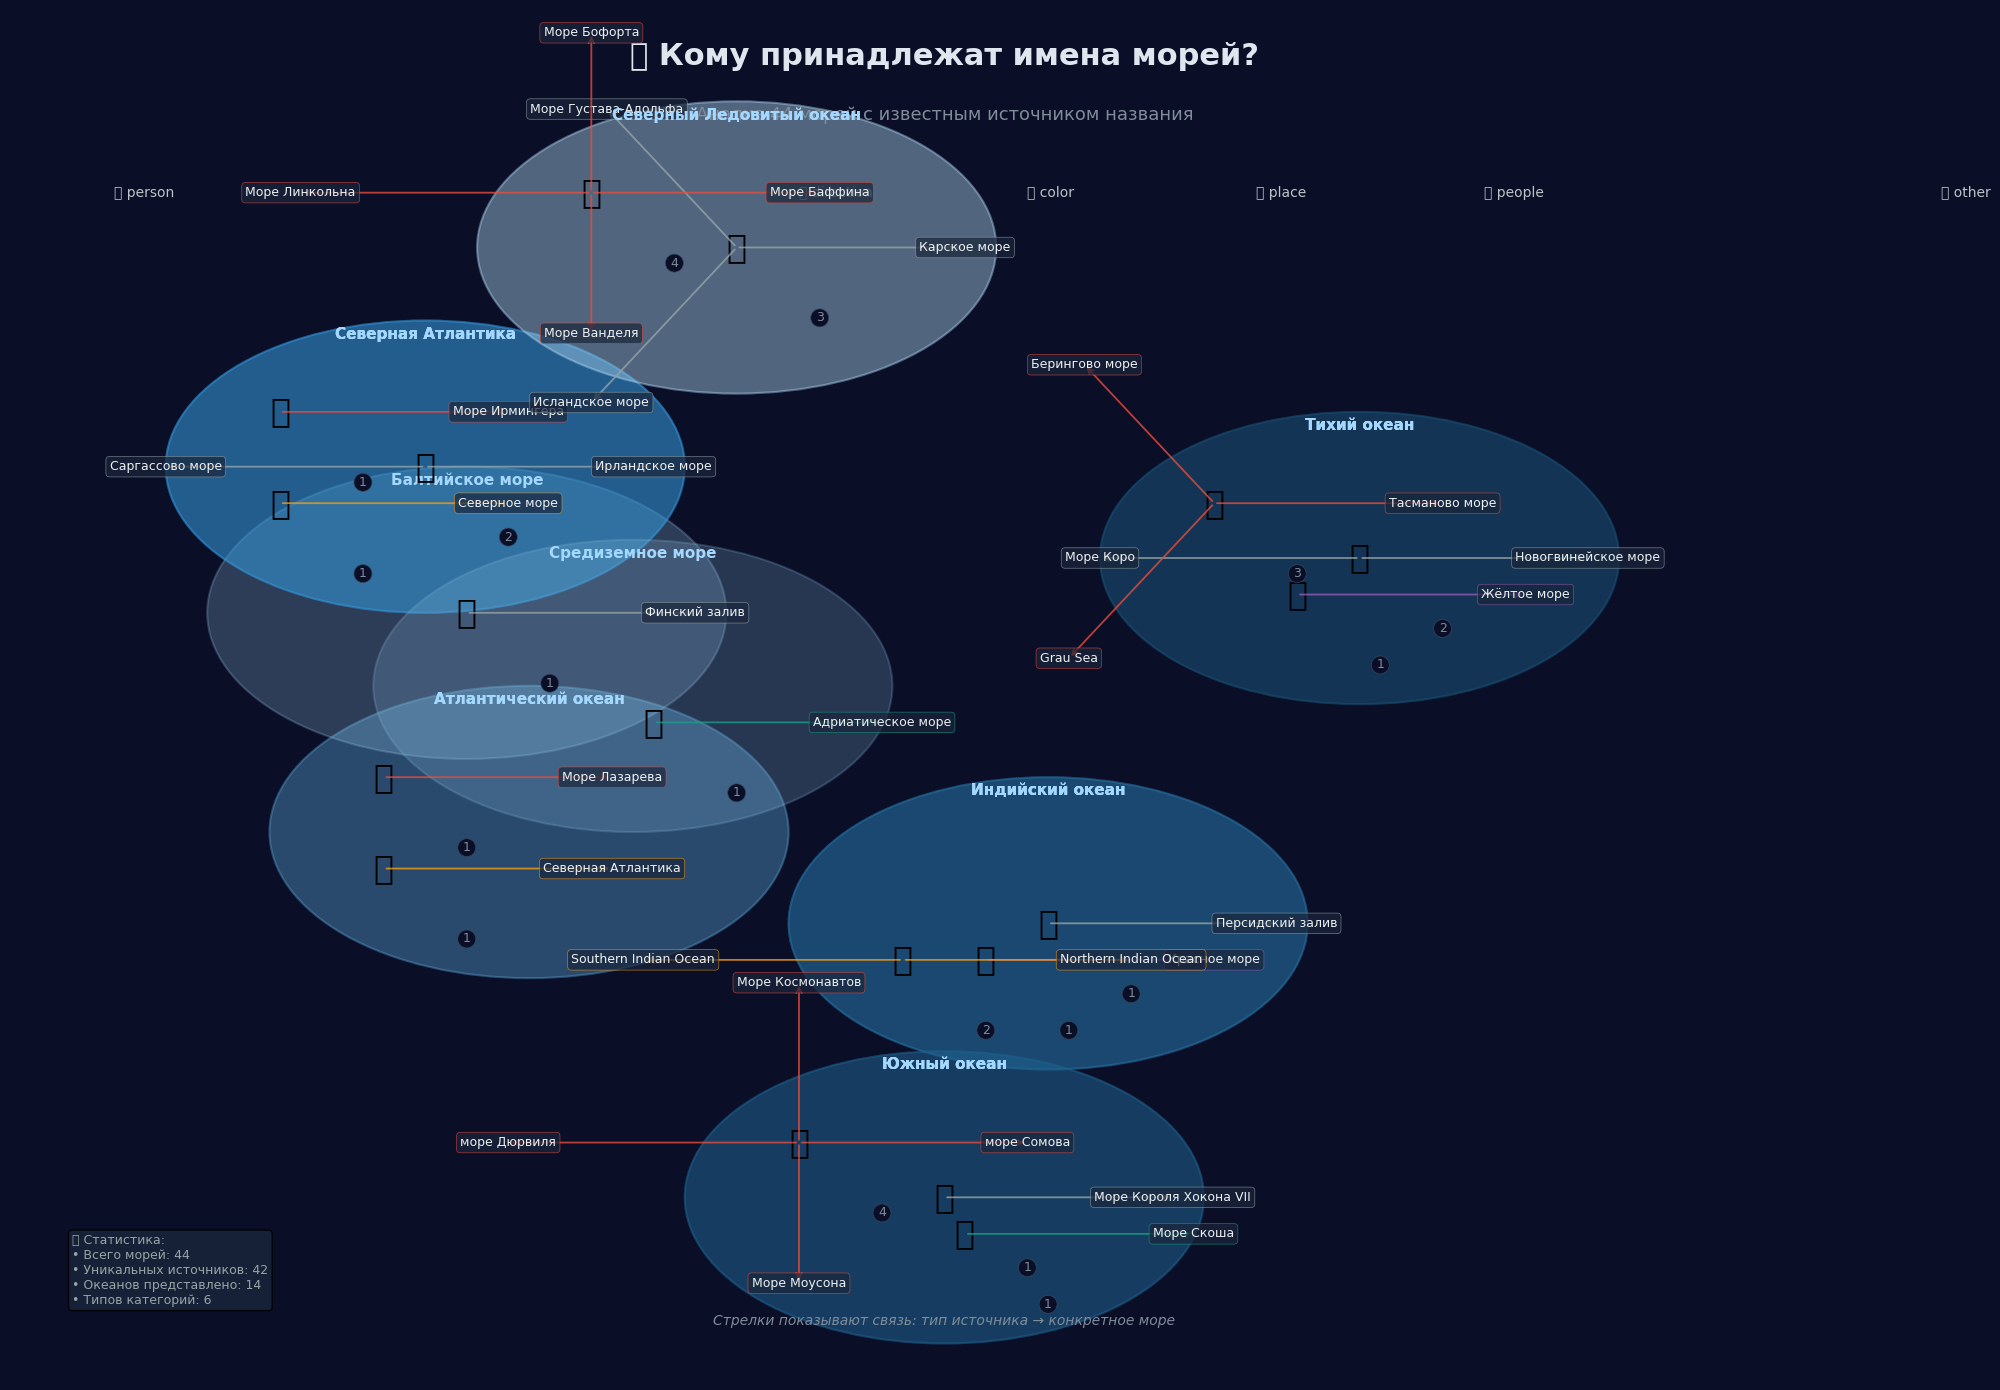

In [ ]:
# 🔍 Подзадача 1: Изучаем уникальные значения в named_after
print("📊 Топ-20 источников названий морей (из 44 записей с данными):")
print("-"*70)
print(df_named['named_after'].value_counts().head(20).to_frame())
print(f"\n✅ Всего уникальных значений: {df_named['named_after'].nunique()}")
# 🎨 Подзадача 2: Ручная категоризация источников названий
# Это творческая работа — вы решаете, кто есть кто!

category_map = {
    # 👤 ЛЮДИ (мореплаватели, исследователи, учёные)
    'Абел Янсзон Тасман': 'person',
    'Витус Ионассен Беринг': 'person',
    'Михаил Михайлович Сомов': 'person',
    'Михаил Петрович Лазарев': 'person',
    'Мигель Грау': 'person',
    'Уильям Баффин': 'person',
    'Фрэнсис Бофорт': 'person',
    'Карл Людвиг Христиан Ирмингер': 'person',
    'Роберт Тодд Линкольн': 'person',
    'Карл Фредерик Вандель': 'person',
    'Жюль Себастьен Сезар Дюмон-Дюрвиль': 'person',
    'Дуглас Моусон': 'person',
    'Ольга Николаевна': 'person',
    'космонавт': 'person',  # обобщённая категория

    # 🌍 СТРАНЫ / РЕГИОНЫ
    'Норвегия': 'country',
    'Индия': 'country',
    'Китай': 'country',
    'Аравия': 'region',
    'Адриатика': 'region',
    'Америка': 'region',
    'Европа': 'region',
    'Африка': 'region',
    'Азия': 'region',
    'Индийский океан': 'region',  # названо в честь океана
    'Атлантида': 'myth',  # мифический регион → мифология

    # 🏔 ГЕОГРАФИЧЕСКИЕ ОБЪЕКТЫ / НАПРАВЛЕНИЯ
    'север': 'direction',
    'юг': 'direction',
    'восток': 'direction',
    'запад': 'direction',
    'красный': 'color',
    'жёлтый': 'color',
    'белый': 'color',
    'чёрный': 'color',
    'Scotia': 'place',  # географическое название
    'Адрия': 'place',
    'Касситы': 'people',  # древний народ
    'германцы': 'people',

    # ⚡ МИФОЛОГИЯ (если встретится)
    # 'Посейдон': 'myth',
    # 'Атлант': 'myth',

    # ❓ ДРУГОЕ (по умолчанию)
}

# Применяем словарь + заполняем пропуски как 'other'
df_named['named_type'] = df_named['named_after'].map(category_map).fillna('other')

# Проверяем результат
print("📊 Распределение по типам источников названий:")
print("-"*50)
print(df_named['named_type'].value_counts().to_frame())
# 🎨 Подзадача 3: Позиции океанов на плоскости (художественная компоновка)
# Координаты (x, y) — примерные, для визуального баланса

ocean_positions = {
    'Тихий океан':                (6.5, 4.5),
    'Индийский океан':            (5.0, 2.5),
    'Северная Атлантика':         (2.0, 5.0),
    'Атлантический океан':        (2.5, 3.0),
    'Северный Ледовитый океан':   (3.5, 6.2),
    'Южный океан':                (4.5, 1.0),
    'Средиземное море':           (3.0, 3.8),
    'Эгейское море':              (3.2, 3.5),
    'Балтийское море':            (2.2, 4.2),
    'Южно-Китайское море':        (6.0, 3.0),
    # Для океанов без точных данных — резервные позиции
    'Восточная Балтика':          (2.3, 4.0),
    'Восточное Средиземноморье':  (3.3, 3.6),
}

# Иконки категорий (эмодзи)
category_icons = {
    'person':     '🧑',   # человек
    'country':    '🌍',   # страна
    'region':     '🗺️',   # регион
    'direction':  '🧭',   # направление
    'color':      '🎨',   # цвет
    'place':      '🏔️',   # место
    'people':     '👥',   # народ
    'myth':       '⚡️',   # мифология
    'other':      '❓',   # другое
}

# Цвета для зон океанов
ocean_colors = {
    'Тихий океан':              '#1a5276',
    'Индийский океан':          '#2874a6',
    'Северная Атлантика':       '#3498db',
    'Атлантический океан':      '#5499c7',
    'Северный Ледовитый океан': '#aed6f1',
    'Южный океан':              '#1f618d',
    'Средиземное море':         '#7fb3d5',
    'Эгейское море':            '#85c1e2',
    'Балтийское море':          '#99c9e8',
    'Южно-Китайское море':      '#2e86ab',
}

# Цвета стрелок по типам категорий
type_arrow_colors = {
    'person':    '#e74c3c',   # красный
    'country':   '#27ae60',   # зелёный
    'region':    '#2980b9',   # синий
    'direction': '#f39c12',   # оранжевый
    'color':     '#9b59b6',   # фиолетовый
    'place':     '#16a085',   # бирюзовый
    'people':    '#d35400',   # тёмно-оранжевый
    'myth':      '#8e44ad',   # тёмно-фиолетовый
    'other':     '#95a5a6',   # серый
}
# 🖌️ Подзадача 4: Рисуем финальную визуализацию
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
import numpy as np
import random

# Настройка фигуры
fig, ax = plt.subplots(figsize=(20, 14), dpi=100)
fig.patch.set_facecolor('#0a0e27')  # тёмно-синий фон
ax.set_facecolor('#0a0e27')
ax.set_xlim(0, 9)
ax.set_ylim(0, 7.5)
ax.axis('off')

# Заголовок
ax.text(4.5, 7.2, '🌊 Кому принадлежат имена морей?',
        fontsize=22, color='#e0e6ed', ha='center', fontweight='bold')
ax.text(4.5, 6.9, f'Анализ {len(df_named)} морей с известным источником названия',
        fontsize=13, color='#7f8c9a', ha='center')

# Легенда типов категорий (в углу)
legend_y = 6.5
for i, (ctype, icon) in enumerate(category_icons.items()):
    if ctype in df_named['named_type'].values:
        ax.text(0.5 + i*1.1, legend_y, f'{icon} {ctype}',
                fontsize=10, color='#bdc3c7', va='center')

# Группируем данные: океан → тип категории → список морей
grouped = df_named.groupby(['ocean', 'named_type'])['sea'].apply(list).reset_index()

# Словарь для отслеживания позиций иконок внутри зон (чтобы не накладывались)
icon_offsets = {
    'person': (-0.7, 0.3), 'country': (-0.3, 0.3), 'region': (0.1, 0.3),
    'direction': (-0.7, -0.2), 'color': (-0.3, -0.2), 'place': (0.1, -0.2),
    'people': (0.5, 0.3), 'myth': (0.5, -0.2), 'other': (0, 0)
}

# Счётчик для размещения названий морей вокруг иконки
sea_counter = {}

# === ЦИКЛ ПО ВСЕМ ЗАПИСЯМ ===
for _, row in grouped.iterrows():
    ocean = row['ocean']
    named_type = row['named_type']
    seas_list = row['sea']

    # Пропускаем, если океан не в позициях или нет цвета
    if ocean not in ocean_positions or ocean not in ocean_colors:
        continue

    cx, cy = ocean_positions[ocean]
    ocean_color = ocean_colors[ocean]

    # 1️⃣ Рисуем зону океана (эллипс)
    zone = Ellipse((cx, cy), width=2.5, height=1.6,
                   color=ocean_color, alpha=0.25,
                   edgecolor=ocean_color, linewidth=1.5)
    ax.add_patch(zone)

    # Подпись океана
    ax.text(cx, cy + 0.7, ocean,
            color='#a5d8ff', ha='center', fontsize=11, fontweight='bold')

    # 2️⃣ Позиция иконки категории внутри зоны
    icon_dx, icon_dy = icon_offsets.get(named_type, (0, 0))
    icon_x, icon_y = cx + icon_dx, cy + icon_dy

    # Рисуем иконку (эмодзи)
    ax.text(icon_x, icon_y, category_icons.get(named_type, '❓'),
            fontsize=24, ha='center', va='center')

    # 3️⃣ Рисуем стрелки от иконки к морям
    # Используем радиальное расположение вокруг иконки
    n_seas = len(seas_list)

    for idx, sea_name in enumerate(seas_list):
        # Угол для размещения (равномерно по кругу)
        angle = 2 * np.pi * idx / max(n_seas, 1)
        radius = 1.1 + (idx % 3) * 0.15  # немного вариации радиуса

        # Позиция названия моря
        sea_x = icon_x + radius * np.cos(angle)
        sea_y = icon_y + radius * np.sin(angle) * 0.7  # сплющиваем по Y

        # Цвет стрелки по типу категории
        arrow_color = type_arrow_colors.get(named_type, '#95a5a6')

        # Рисуем стрелку
        ax.annotate('',
                   xy=(sea_x, sea_y),
                   xytext=(icon_x, icon_y),
                   arrowprops=dict(arrowstyle='->',
                                 color=arrow_color,
                                 lw=1.3,
                                 alpha=0.8))

        # Подпись моря
        ax.text(sea_x, sea_y, sea_name,
               fontsize=9, color='#ecf0f1',
               ha='center', va='center',
               bbox=dict(boxstyle='round,pad=0.3',
                        facecolor='#1a253a',
                        edgecolor=arrow_color,
                        alpha=0.7, linewidth=0.5))

    # 4️⃣ Счётчик: сколько морей этого типа в этом океане
    count_text = f'{len(seas_list)}'
    ax.text(icon_x + 0.4, icon_y - 0.35, count_text,
           fontsize=9, color='#7f8c9a',
           ha='center', va='top',
           bbox=dict(boxstyle='circle,pad=0.2',
                    facecolor='#0a0e27',
                    edgecolor='#34495e',
                    linewidth=0.5))

# === ДОПОЛНИТЕЛЬНО: Сводная статистика в углу ===
stats_text = (f"📊 Статистика:\n"
              f"• Всего морей: {len(df_named)}\n"
              f"• Уникальных источников: {df_named['named_after'].nunique()}\n"
              f"• Океанов представлено: {df_named['ocean'].nunique()}\n"
              f"• Типов категорий: {df_named['named_type'].nunique()}")

ax.text(0.3, 0.8, stats_text,
        fontsize=9, color='#95a5a6',
        va='top', ha='left',
        bbox=dict(boxstyle='round', facecolor='#1a253a', alpha=0.8))

# === Подпись внизу ===
ax.text(4.5, 0.3, 'Стрелки показывают связь: тип источника → конкретное море',
        fontsize=10, color='#7f8c9a', ha='center', style='italic')

# Настройка отображения
plt.tight_layout()
plt.savefig('viz4_sea_names_graph.png',
           dpi=150, bbox_inches='tight',
           facecolor=fig.get_facecolor())
print("✅ Визуализация сохранена: viz4_sea_names_graph.png")
plt.show()
# 🔁 Альтернатива: названия морей вынесены за пределы зоны
# Замените блок с циклом по seas_list на этот:

for idx, sea_name in enumerate(seas_list):
    # Чётные/нечётные — разные стороны от иконки
    side = 1 if idx % 2 == 0 else -1
    angle = np.pi/4 * side + (idx // 2) * 0.3

    radius = 1.4  # фиксированный вынос
    sea_x = icon_x + radius * np.cos(angle)
    sea_y = icon_y + radius * np.sin(angle) * 0.6

    arrow_color = type_arrow_colors.get(named_type, '#95a5a6')

    # Стрелка с изгибом (через кривую Безье)
    ax.annotate('',
               xy=(sea_x, sea_y),
               xytext=(icon_x, icon_y),
               arrowprops=dict(arrowstyle='->',
                             color=arrow_color,
                             lw=1.2,
                             alpha=0.7,
                             connectionstyle='arc3,rad=0.2'))

    # Название с выравниванием по стороне
    ha = 'left' if side > 0 else 'right'
    ax.text(sea_x + 0.15*side, sea_y, sea_name,
           fontsize=9, color='#ecf0f1',
           ha=ha, va='center',
           bbox=dict(boxstyle='round,pad=0.3',
                    facecolor='#1a253a',
                    edgecolor=arrow_color,
                    alpha=0.8, linewidth=0.5))

